# Spatiotemporal Hawkes (ETAS-style) — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/hawkes_spatiotemporal_from_scratch_and_numpyro.ipynb)

Self-exciting spatiotemporal point processes — **Hawkes** processes — model events that *trigger* further events. The conditional intensity given the history $\mathcal H_t$ takes the ETAS-style form

$$
\lambda^*(s, t) = \mu + \sum_{t_i < t} \alpha\, \beta e^{-\beta(t - t_i)}\, \mathcal{N}(s; s_i, \sigma^2 I).
$$

Each past event $i$ leaves a Gaussian-shaped "aftershock cloud" in space and an exponential decay in time. The branching ratio is $\alpha$ (sub-critical when $\alpha < 1$ — the spatial and temporal kernels each integrate to 1, so the dimensional check works out).

This notebook walks through the operator, sampler, and a NumPyro fit that recovers $\mu, \alpha, \beta, \sigma$ from a single realisation.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes import RectangularDomain, TemporalDomain
from xtremax.point_processes.distributions import (
    SpatioTemporalHawkes as StHawkesDist,
)
from xtremax.point_processes.operators import (
    SpatioTemporalHawkes as StHawkesOp,
)
from xtremax.point_processes.primitives import (
    stpp_hawkes_intensity,
    stpp_hawkes_log_prob,
)


plt.rcParams["figure.figsize"] = (8.0, 4.0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. From scratch — sample a sub-critical Hawkes realisation

In [2]:
spatial = RectangularDomain.from_size(jnp.array([10.0, 10.0]))
temporal = TemporalDomain.from_duration(5.0)

mu_true, alpha_true, beta_true, sigma_true = 0.2, 0.4, 1.5, 0.6
op = StHawkesOp(
    mu=mu_true,
    alpha=alpha_true,
    beta=beta_true,
    sigma=sigma_true,
    spatial=spatial,
    temporal=temporal,
)
locs, times, mask, n = op.sample(random.PRNGKey(0), max_events=1024)
print(f"Sampled {int(n)} events (sub-critical α={alpha_true} < 1).")

Sampled 100 events (sub-critical α=0.4 < 1).


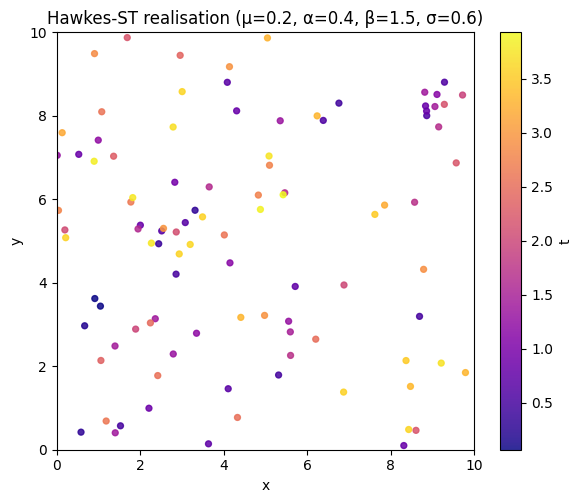

In [3]:
real_locs = locs[mask]
real_times = times[mask]
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    real_locs[:, 0], real_locs[:, 1], c=real_times, s=18, alpha=0.85, cmap="plasma"
)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(
    f"Hawkes-ST realisation (μ={mu_true}, α={alpha_true}, β={beta_true}, σ={sigma_true})"
)
plt.colorbar(sc, ax=ax, label="t")
plt.tight_layout()
plt.show()

Notice the clusters: events are not uniformly scattered in space-time, even though $\mu$ alone is constant. The excitation kernel concentrates aftershock-like sequences near each "parent" event.

### Conditional intensity at a query

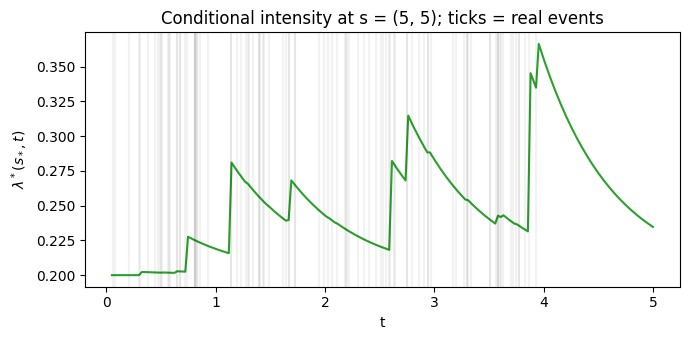

In [4]:
# Pick a point near the cluster centroid and inspect the time-evolution
# of λ* there.
s_query = jnp.array([5.0, 5.0])
t_grid = jnp.linspace(0.05, 5.0, 200)


def lam_at(t):
    return stpp_hawkes_intensity(
        s_query,
        t,
        locs,
        times,
        mask,
        mu=mu_true,
        alpha=alpha_true,
        beta=beta_true,
        sigma=sigma_true,
    )


lam_curve = jax.vmap(lam_at)(t_grid)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(t_grid, lam_curve, "C2-", label=r"$\lambda^*(s_*, t)$")
for t_event in real_times:
    ax.axvline(float(t_event), color="k", alpha=0.05)
ax.set_xlabel("t")
ax.set_ylabel(r"$\lambda^*(s_*, t)$")
ax.set_title("Conditional intensity at s = (5, 5); ticks = real events")
plt.tight_layout()
plt.show()

### Closed-form log-likelihood

`stpp_hawkes_log_prob` evaluates $\sum_i \log \lambda^*(s_i, t_i) - \Lambda$ in O(n²) over the events. The compensator $\Lambda$ uses the analytic axis-wise erf-CDF for the spatial Gaussian when `boundary_correction=True`.

In [5]:
log_p = stpp_hawkes_log_prob(
    locs,
    times,
    mask,
    mu=mu_true,
    alpha=alpha_true,
    beta=beta_true,
    sigma=sigma_true,
    spatial=spatial,
    temporal=temporal,
)
print(f"log L = {float(log_p):.3f}")

log L = -257.481


## 2. With NumPyro — recover (μ, α, β, σ)

Use weakly-informative priors that respect positivity and sub-criticality. NUTS works fine here because the closed-form compensator gives exact gradients.

In [6]:
def model(locs_obs, times_obs, mask_obs, spatial, temporal):
    mu = numpyro.sample("mu", dist.LogNormal(loc=jnp.log(0.2), scale=0.5))
    alpha = numpyro.sample("alpha", dist.Beta(concentration1=2.0, concentration0=4.0))
    beta = numpyro.sample("beta", dist.LogNormal(loc=jnp.log(1.0), scale=0.5))
    sigma = numpyro.sample("sigma", dist.LogNormal(loc=jnp.log(0.5), scale=0.3))
    spp = StHawkesDist(
        mu=mu,
        alpha=alpha,
        beta=beta,
        sigma=sigma,
        spatial=spatial,
        temporal=temporal,
        max_events=mask_obs.shape[0],
    )
    numpyro.factor("lik", spp.log_prob((locs_obs, times_obs, mask_obs)))


mcmc = MCMC(
    NUTS(model), num_warmup=400, num_samples=800, num_chains=1, progress_bar=False
)
mcmc.run(
    random.PRNGKey(1),
    locs_obs=locs,
    times_obs=times,
    mask_obs=mask,
    spatial=spatial,
    temporal=temporal,
)
post = mcmc.get_samples()
for name, true_val in [
    ("mu", mu_true),
    ("alpha", alpha_true),
    ("beta", beta_true),
    ("sigma", sigma_true),
]:
    samples = post[name]
    print(
        f"{name:>5}: posterior mean = {float(jnp.mean(samples)):.3f}, "
        f"95% CI = [{float(jnp.quantile(samples, 0.025)):.3f}, "
        f"{float(jnp.quantile(samples, 0.975)):.3f}], true = {true_val}"
    )

   mu: posterior mean = 0.141, 95% CI = [0.101, 0.187], true = 0.2
alpha: posterior mean = 0.356, 95% CI = [0.153, 0.583], true = 0.4
 beta: posterior mean = 1.622, 95% CI = [0.744, 3.027], true = 1.5
sigma: posterior mean = 0.530, 95% CI = [0.358, 0.731], true = 0.6


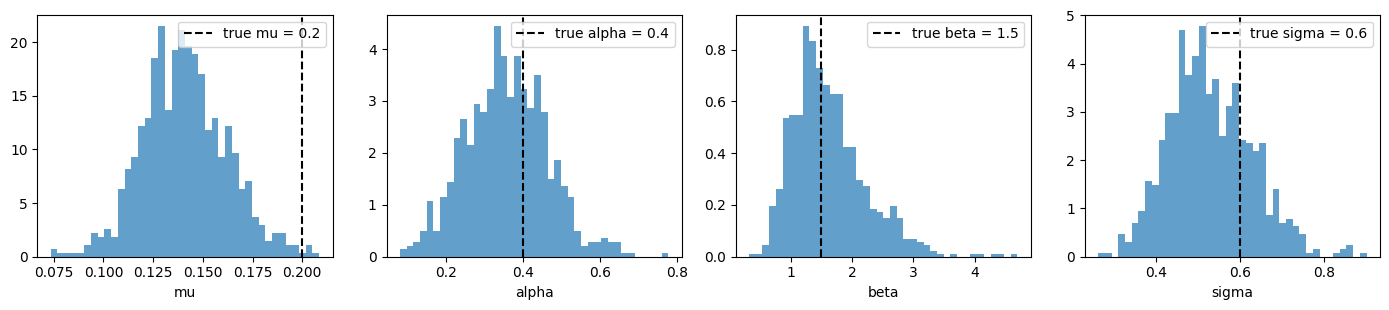

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, name, true_val in zip(
    axes, ["mu", "alpha", "beta", "sigma"], [mu_true, alpha_true, beta_true, sigma_true]
):
    ax.hist(post[name], bins=40, density=True, alpha=0.7, color="C0")
    ax.axvline(true_val, color="k", linestyle="--", label=f"true {name} = {true_val}")
    ax.set_xlabel(name)
    ax.legend()
plt.tight_layout()
plt.show()

A single realisation is enough to localise $\mu, \alpha, \beta, \sigma$ when the slab is large relative to the kernel bandwidth. Expect $\sigma$ to be the most poorly identified — bandwidth and amplitude trade off when the cluster count is small.